# Лабораторная работа №1

## Загрузка и подготовка данных

Импорт необходимых библиотек для этого этапа.

In [298]:
import pandas as pd
import numpy as np

Чтение датасета.

In [299]:
df = pd.read_csv("data/student_lifestyle_100k.csv")

Посмотрим заголовок таблицы и первые строки.

In [300]:
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Посмотрим информацию о data frame.

In [301]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Проверим на дубликаты и на количество пропущенных значений.

In [302]:
df.duplicated().sum()

np.int64(0)

Видим: в df нет дубликатов. Никаких дейтсвий по их очистке делать не требуется. Запомним этот факт.

Теперь проверим на количество пропусков в каждой колонке.

In [303]:
df.isna().sum()  # axis = 0 => сумма по столбцам

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Видим: в df нет ни одного пропуска во всех колонках. Запомним этот факт, и далее опустим все проверки на пропуски.

Удалим неинтересующую нас колонку 'Student_ID', а остальные для удобства переименуем. 

In [304]:
df = df.drop(["Student_ID"], axis=1)

df = df.rename(
    columns={
        "Department": "Profile",
        "Sleep_Duration": "Sleep",
        "Study_Hours": "Study",
        "Social_Media_Hours": "Media",
        "Physical_Activity": "Sport",
        "Stress_Level": "Stress",
    }
)

Также заметим: значения в новой колонке 'Spor' приведены как минуты в неделю. Для удобства оанализа преобразуем их к часы в день. Тогда колонки 'Sport', 'Media', 'Sleep', 'Study' будут иметь одинаковые единицы измерения.

In [305]:
df["Sport"] = df["Sport"] / (60 * 7)

In [306]:
df.head()

,Age,Gender,Profile,CGPA,Sleep,Study,Media,Sport,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,0.271429,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,0.338095,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,0.326190,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,0.309524,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,0.009524,6,False


Теперь проверим, что в данных нет логических ошибок. Для удобства вставлю исходное описание:
| Название столбца         | Описание                                                        | Тип данных          |
|--------------------------|-----------------------------------------------------------------|---------------------|
| Age                      | Возраст студента (18-24)                                        | Целое число         |
| Gender                   | Пол студента (мужской/женский)                                  | Строка              |
| Department               | Область обучения (инженерное дело, бизнес, искусство и т. д.)    | Строка              |
| CGPA                     | Средний балл успеваемости (0.0 - 4.0)                           | Число с плавающей запятой |
| Sleep_Duration           | Среднее количество часов сна в сутки                            | Число с плавающей запятой |
| Study_Hours              | Среднее количество часов, затраченных на учебу в день           | Число с плавающей запятой |
| Social_Media_Hours       | Среднее количество часов, проведённых в социальных сетях в день | Число с плавающей запятой |
| Physical_Activity        | Среднее количество минут физической активности в неделю         | Целое число         |
| Stress_Level             | Уровень стресса, по самооценке (шкала 0-10)                     | Целое число         |
| Depression               | Состояние психического здоровья (True = Вероятная депрессия, False = Здоровый) | Логическое значение |

In [307]:
# Все значения в полях колонок отражающих время - неотрицательные
negative_rows = (
    (df["Study"] < 0) | (df["Sleep"] < 0) | (df["Media"] < 0) | (df["Sport"] < 0)
)

print("Строк с отрицательным временем нет: ", negative_rows.sum() == 0)

# Проверим что нету строк со значениями по времени > 15ч
extrime_rows = (
    (df["Study"] > 15) | (df["Sleep"] > 15) | (df["Media"] > 15) | (df["Sport"] > 15)
)

print("Строк с экстримальм временем (> 15ч) нет: ", extrime_rows.sum() == 0)

# Проверим, что в колонке со значем пол только 2 значения
unique_gender = df["Gender"].unique()
print("Пол только м. и ж.: ", len(unique_gender) == 2)

# Проверим, что 0 < CGPA < 4
row_error_cgpa = (df["CGPA"] < 0) | (df["CGPA"] > 4)
print("Значения CGPA лежат в [0, 4]: ", row_error_cgpa.sum() == 0)

# Проверим, что возраст студентов лежит в [18, 24]
row_error_age = (df["Age"] < 18) | (df["Age"] > 24)
print("Возраст студентов лежит в [18, 24]: ", row_error_cgpa.sum() == 0)

# Проверим, сколько будет сумма часов указанных в сутки для каждого студенка
sum_hours_per_day = df["Sleep"] + df["Study"] + df["Media"] + df["Sport"]
hours_unknown = np.zeros(len(sum_hours_per_day), dtype=float) * 24 - sum_hours_per_day

print("Min указанные часы в день: ", min(sum_hours_per_day))
print("Max указанные часы в день: ", max(sum_hours_per_day))

extreme_sum_hours_per_day = sum_hours_per_day > 24
print(
    "Количество студентов с сумой времени > 24ч в день:",
    extreme_sum_hours_per_day.sum(),
)
# Тут есть значение > 27ч, нижи попробую предположить почему это могло произойти

# Проверим, что уровень стресса лежит в [0, 10]
row_error_stress = (df["Stress"] < 0) | (df["Stress"] > 10)
print("Ошибок в колонке Stress нет: ", row_error_stress.sum() == 0)

Строк с отрицательным временем нет:  True
Строк с экстримальм временем (> 15ч) нет:  True
Пол только м. и ж.:  True
Значения CGPA лежат в [0, 4]:  True
Возраст студентов лежит в [18, 24]:  True
Min указанные часы в день:  3.6
Max указанные часы в день:  27.361904761904764
Количество студентов с сумой времени > 24ч в день: 109
Ошибок в колонке Stress нет:  True


Я обнаружил, что у ряда студентов сумма активностей превышает 24 часа (max = 27.36). Я решил оставить эти данные, предполагая возможность совмещения активностей (например, прослушивание аудиокниг во время занятий спортом), так как отклонение не является критическим (менее 15% от 24 часов), но стоить иметь ввиду этот факт. Я не буду считать это ошибкой, и не буду заменять время или же удалять эти строки.

## Разведочный анализ даннх (EDA)

Импортируем дополнительно библиотеки для этого этапа.

In [308]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

Создам копию data frame, чтобы не влиять на исходные данные во время EDA.

In [309]:
eda_df = df.copy()

### Анализ целевых переемнныхпеременных

Гистрограмма для CGPA:

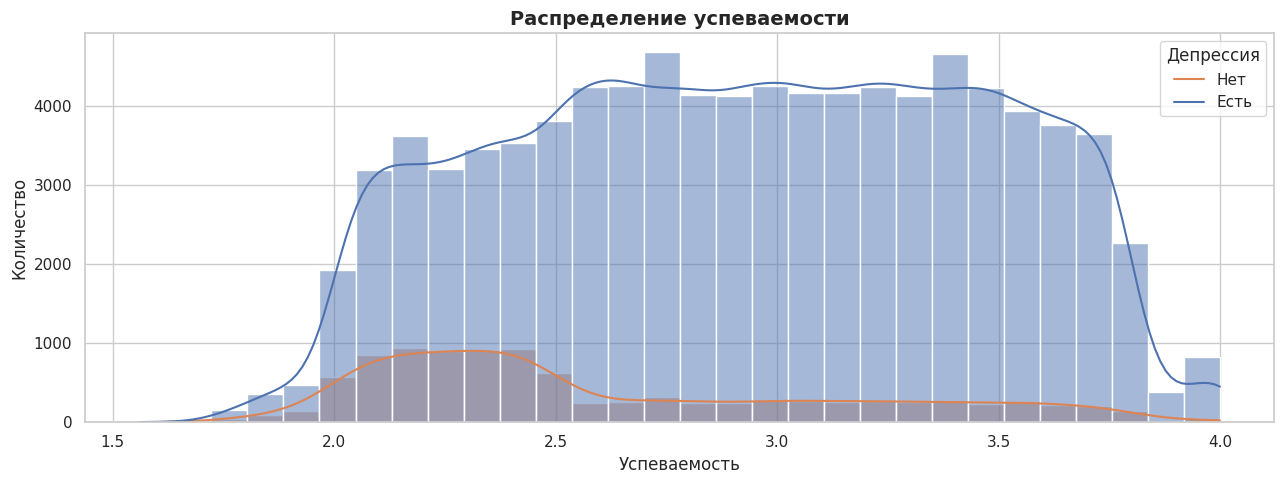

In [310]:
plt.figure(figsize=(13, 5))

sns.histplot(data=eda_df, x="CGPA", kde=True, bins=30, hue="Depression")

plt.xlabel("Успеваемость")
plt.ylabel("Количество")
plt.title("Распределение успеваемости", fontsize=14, fontweight="bold")
plt.legend(title="Депрессия", labels=["Нет", "Есть"])

plt.tight_layout()
plt.show()

Видим, что распределение по успеваемости имеет форму трапеции, с длинным платом, сильных перекосов не видно. Причём, видно, что люди с депрессией чаще имеют более низкую успеваемость и людей с депрессией сильно меньше чем людей без неё, но это первичный анализ. Более подробно это рассмотрим на следующих графиках.

Countplot для Depression:

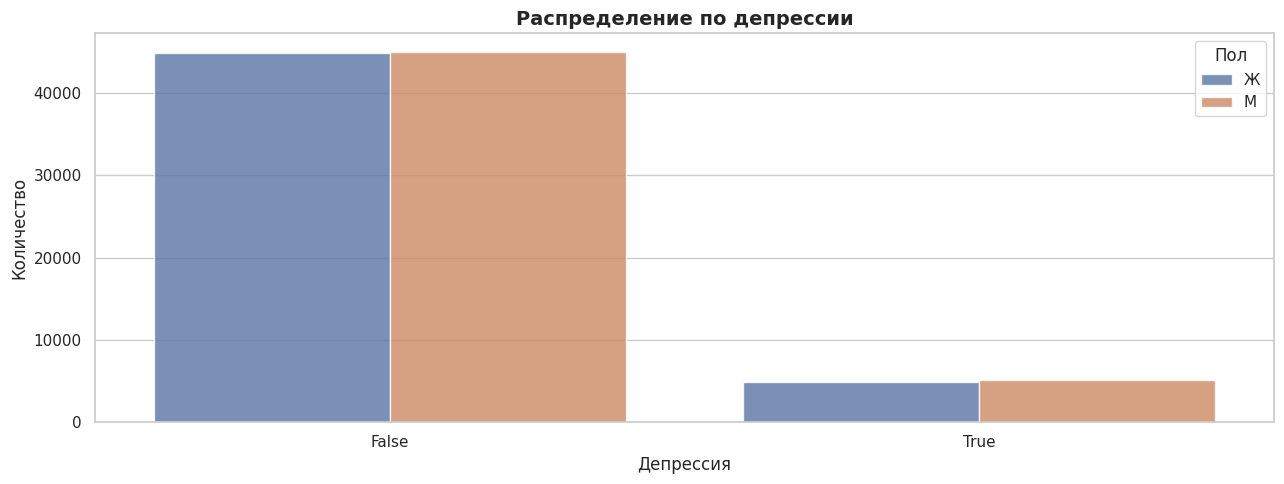

Людей без депрессии: 89938 (89.938%)
Людей с депрессией: 10062 (10.062%)


In [311]:
plt.figure(figsize=(13, 5))

sns.countplot(data=eda_df, x="Depression", hue="Gender", alpha=0.8)

plt.xlabel("Депрессия")
plt.ylabel("Количество")
plt.title("Распределение по депрессии", fontsize=14, fontweight="bold")
plt.legend(title="Пол", labels=["Ж", "М"])

plt.tight_layout()
plt.show()

has_depression = sum(eda_df["Depression"])
has_not_deperssion = len(eda_df[["Depression"]]) - has_depression

depression_persent = 100 * has_depression / len(eda_df[["Depression"]])
not_depression_persent = 100 - depression_persent

print(f"Людей без депрессии: {has_not_deperssion} ({not_depression_persent}%)")
print(f"Людей с депрессией: {has_depression} ({depression_persent}%)")

Наблюдаем, что людей с депрессией сильно меньше чем людей без ней, при этом не видно зависимости от пола. Людей с депрессией примерно 10%, людей без неё примерно 90%. Это означает дисбаланс классов.

### Анализ признаков

#### Анализ числовых признаков

In [312]:
def plot_numeric_feat(series: pd.Series):
    """Функция для построения графиков для числовых признаков."""
    col = series.name

    # Расчёт выбросов
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_low = (series < lower_bound).sum()
    outliers_up = (series > upper_bound).sum()

    outlier_text = (
        f"Нижняя граница выбросов: {lower_bound:.2f} ({outliers_low} шт.)\n"
        if outliers_low
        else f"Верхняя граница выбросов: {upper_bound:.2f} ({outliers_up} шт.)"
        if outliers_up
        else ""
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Гистограма
    sns.histplot(data=df, x=series, bins=30, kde=True, ax=axes[0])
    axes[0].margins(y=0.25)
    axes[0].set_title(f"Распределение: {col}", fontsize=14, fontweight="bold")
    axes[0].legend(labels=["Плотность распределения"], loc="upper left")

    # Статистика
    stats_text = (
        f"Медиана: {series.median():.2f}\n"
        f"Среднее: {series.mean():.2f}\n"
        f"Диапазон: {series.min():.2f} - {series.max():.2f}"
    )

    axes[0].text(
        0.95,
        0.95,
        stats_text,
        transform=axes[0].transAxes,
        fontsize=11,
        va="top",
        ha="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.7),
        ma="left",
    )

    # Boxplot
    sns.boxplot(data=df, x=series, ax=axes[1], color="lightgreen", width=0.4)
    axes[1].margins(y=0.25)
    axes[1].set_title(
        f"Boxplot и Выбросы: {col}", fontsize=13, fontweight="bold", pad=15
    )

    # Статистика на Boxplot
    axes[1].text(
        0.05,
        0.95,
        outlier_text,
        transform=axes[1].transAxes,
        fontsize=11,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.7),
        ma="left",
    )

    plt.tight_layout()
    plt.show()

In [313]:
# Выбираем числовые признаки
numeric_cols = df.select_dtypes(include="number").columns.to_list()
numeric_cols.remove("CGPA")

print(numeric_cols)

['Age', 'Sleep', 'Study', 'Media', 'Sport', 'Stress']


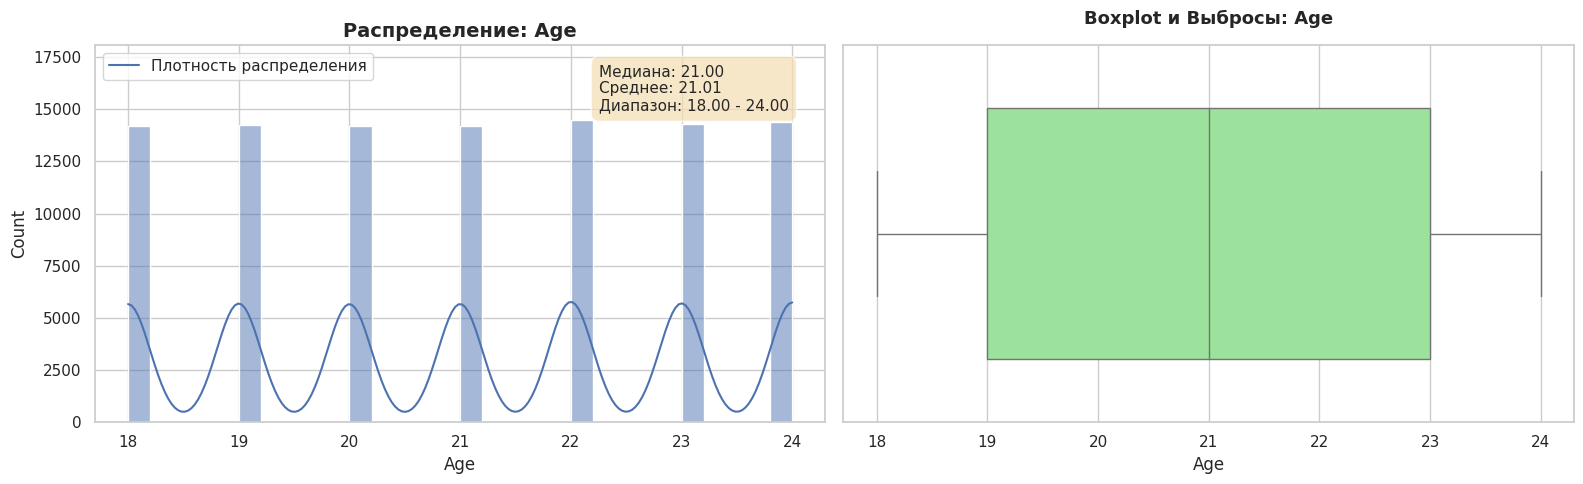

In [314]:
plot_numeric_feat(eda_df["Age"])

Дискретное равномерное разбиение по возрасту от 18 до 24 лет. Выбросы отсутствуют.

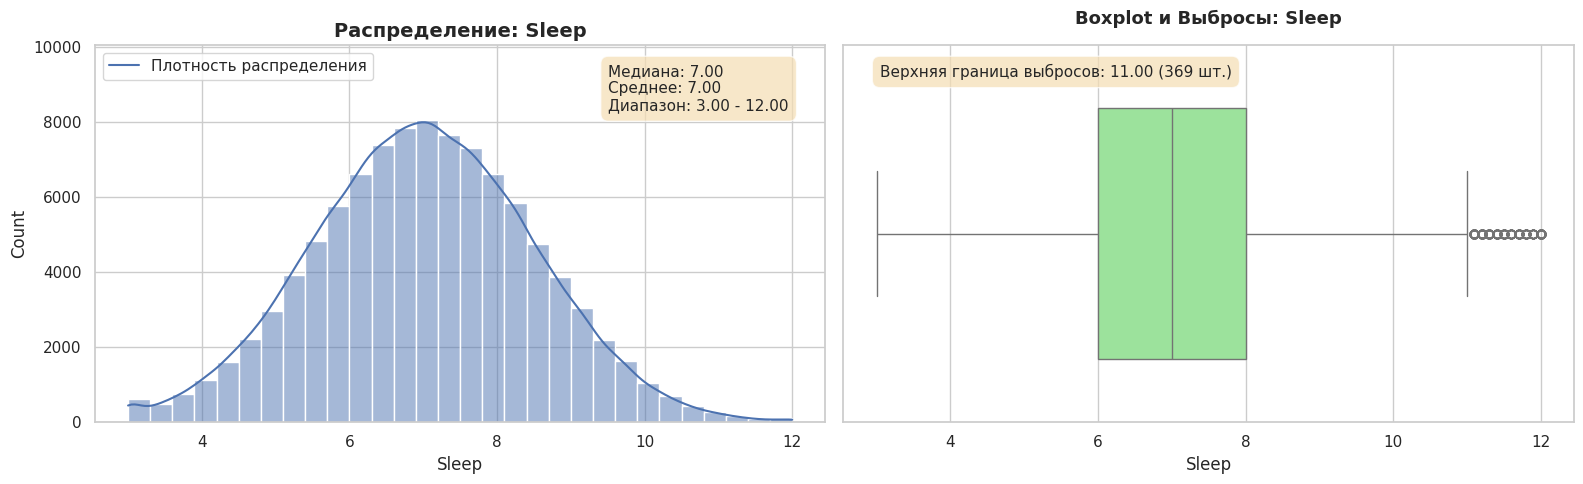

In [315]:
plot_numeric_feat(eda_df["Sleep"])

Распределение нормальное симметричное. Среднее и медиана совпадают. Сильных перекосов нет. Обнаружено 369 выбросов с значениями более 11.0 часов.

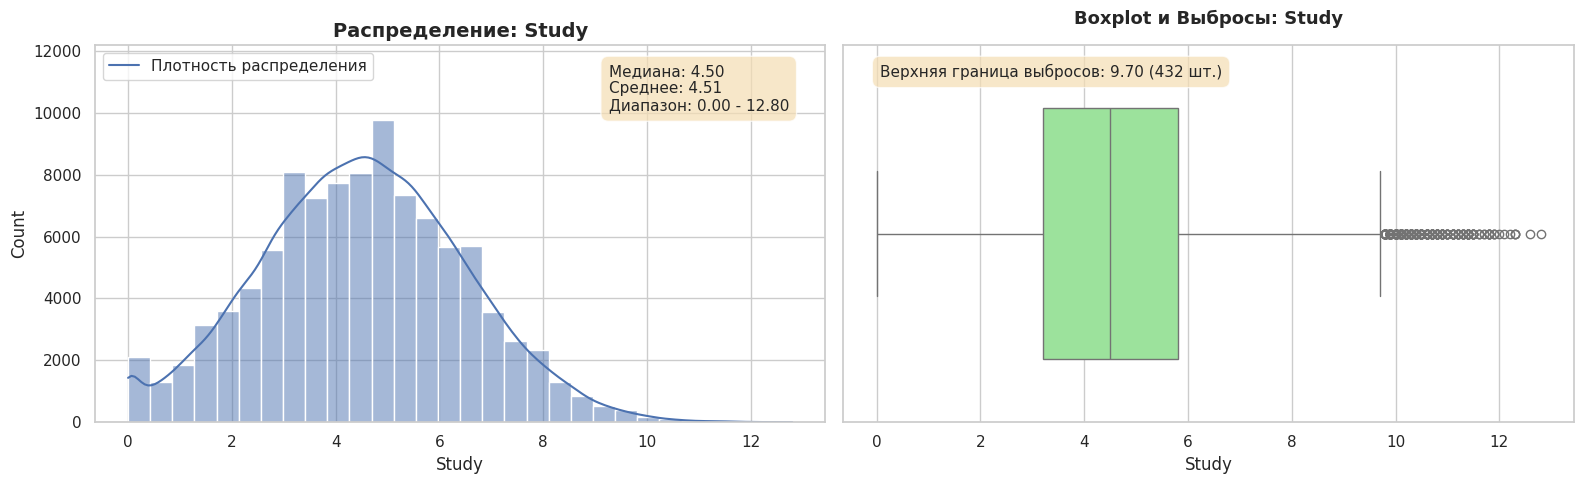

In [316]:
plot_numeric_feat(eda_df["Study"])

В распределении есть перекос в левую сторону. Обнаружено 432 выброса с значениями более 9.7 часов.

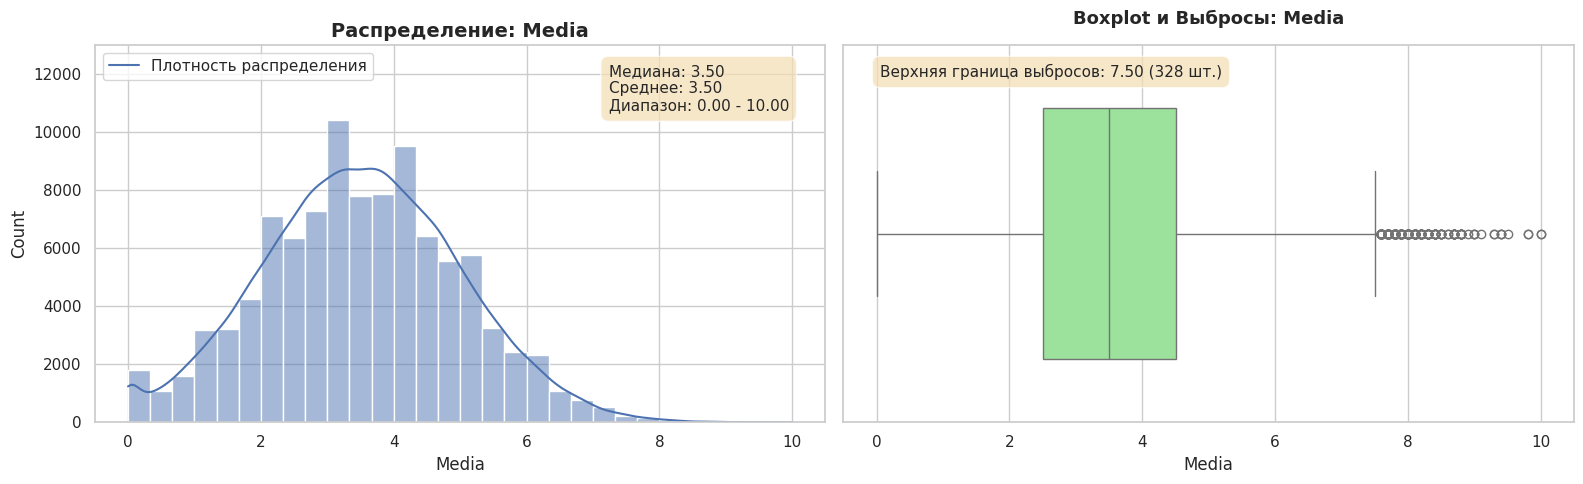

In [317]:
plot_numeric_feat(eda_df["Media"])

В распределении есть перекос в левую сторону, имеет несколько пиков. Обнаружено 328 выбросов с значениями более 7.5 часов.

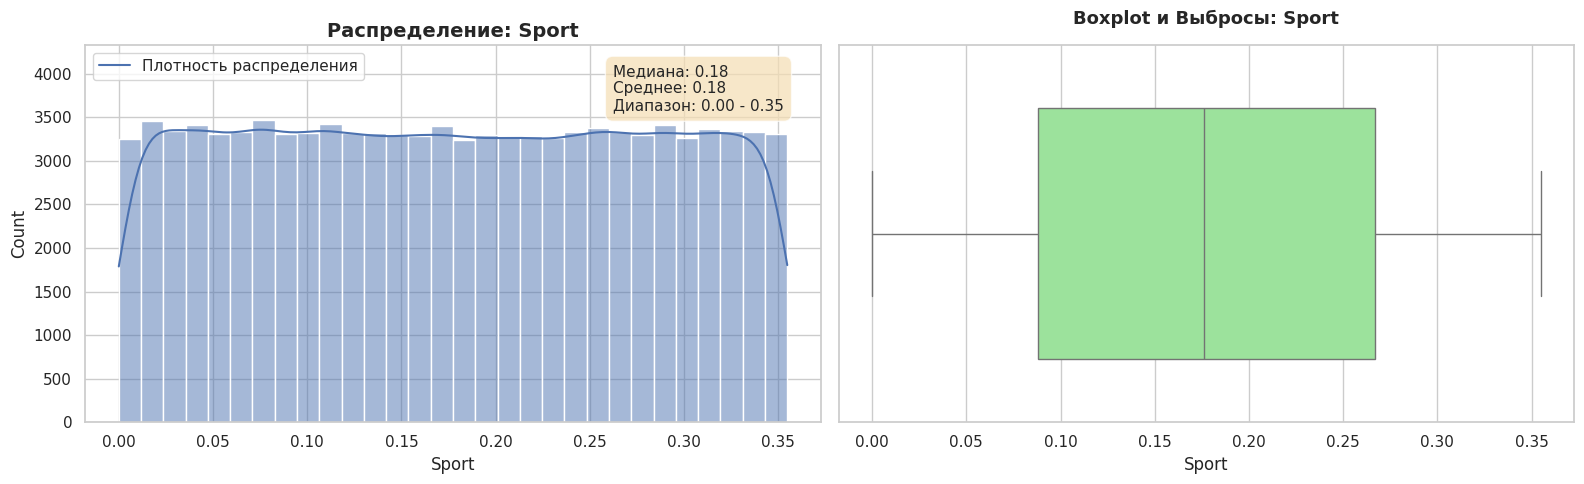

In [318]:
plot_numeric_feat(eda_df["Sport"])

Распределение равномерное. Разброс значений от 0 до 0.35. Выбросов не обнаружено

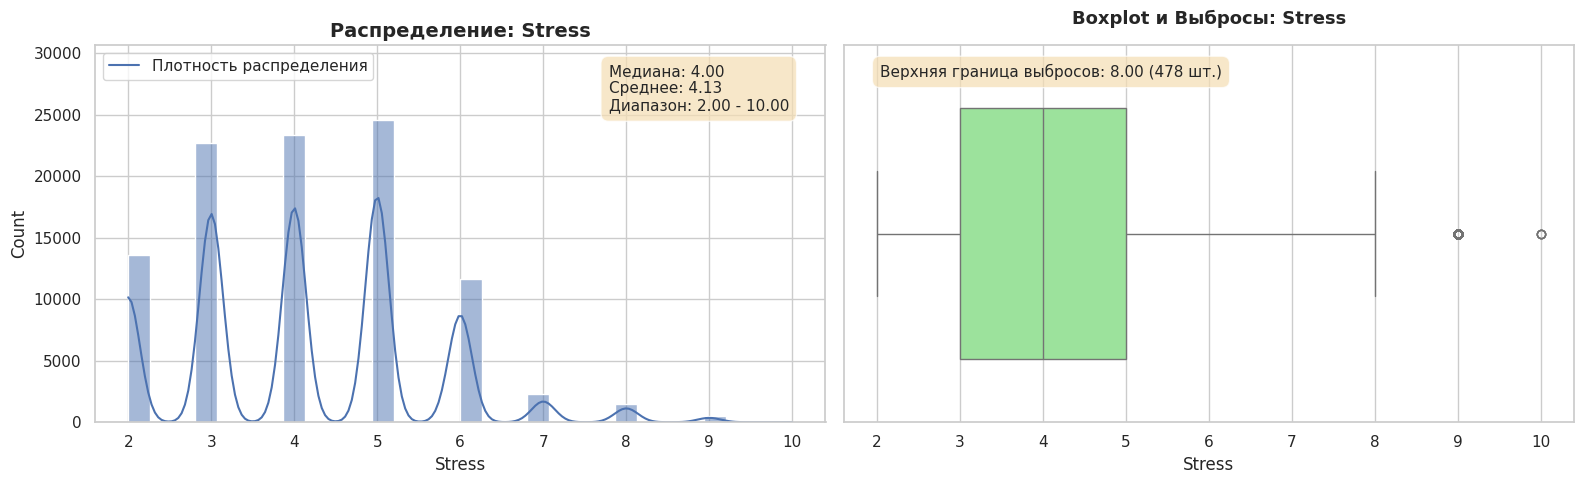

In [319]:
plot_numeric_feat(eda_df["Stress"])

Дискретное распределение c пиками в несколльких значених. Большинство оцениваю стресс как 3 - 5. Обнаружено 478 выбросов с значениями > 8.

#### Выводы по числовым признакам

Количество выбросов в признаках `Sleep`, `Study` и `Media` составляют 300 - 400 случаев из 100000. Это ≈ 0.5% от всей выборки, причем эти все выбросы - правосторонние. Принято решение выполнить коррекцию выбросов - провести винзоризацию на основе межквартильного размаха, т.е. привести все значению к отрезку $[Q1−1.5IQ; Q3+1.5IQR]$.


#### Анализ категориальных признаков

In [320]:
# Выбираем категориальные признаки
cat_cols = df.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns.tolist()
cat_cols.remove("Depression")

# Приводим тип
df[cat_cols] = df[cat_cols].astype("category")

print(cat_cols)

['Gender', 'Profile']


Несмотря на малое количество уникальных значений в признаках `Age` и `Stress`, было решено оставить их числовыми, поскольку эти признаки имеют порядок. Для выбранных `Gender` и `Profile` номинальных  категориальных признаков примененю прямое кодирование `One-Hot Encoding`.

In [321]:
def plot_cat_feat(series: pd.Series):
    """Анализирует распределение категориального признака."""
    feature_name = series.name
    value_counts = series.value_counts()
    total_count = len(series)
    unique_count = len(value_counts)

    # Barplot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    bars = axes[0].barh(value_counts.index[::-1], value_counts[::-1], alpha=0.8)
    axes[0].set_title(f"Частоты: {feature_name}", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Количество")
    axes[0].set_ylabel("Категория")

    # Подписываем значения на столбцах (если их не слишком много)
    if len(value_counts) <= 10:
        for bar in bars:
            width = bar.get_width()
            axes[0].text(
                width + max(value_counts.values) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{int(width)}",
                va="center",
                fontsize=10,
                alpha=0.8,
            )

    # Круговая диаграмма с процентами (поскольку категорий мало, это будет нормально выглядеть)
    colors = sns.color_palette("pastel", len(value_counts))
    axes[1].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        textprops={"fontsize": 10},
        wedgeprops={"edgecolor": "white", "linewidth": 2},  # Окантовка
    )
    axes[1].set_title(f"Доли: {feature_name}", fontsize=14, fontweight="bold")

    # Статистика на графике
    stats_text = (
        f"Категорий: {unique_count}\n"
        f"Топ: {value_counts.index[0]} ({value_counts.values[0] / total_count * 100:.1f}%)"
    )

    axes[1].text(
        -0.15,
        0.15,
        stats_text,
        transform=axes[1].transAxes,
        fontsize=10,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()

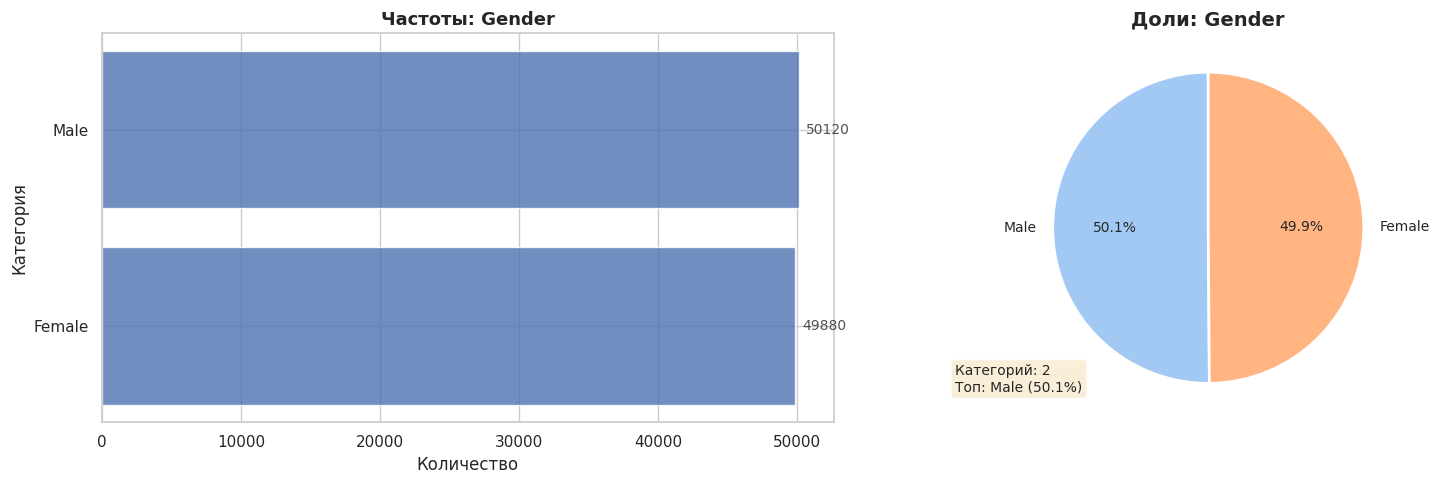

In [322]:
plot_cat_feat(eda_df["Gender"])

Выборка сбалансирована: количество представителей обоих полов практически идентично. Признак является номинальным, поэтому для корректной работы линейных моделей будет применено прямое кодирование `One-Hot Encoding`.

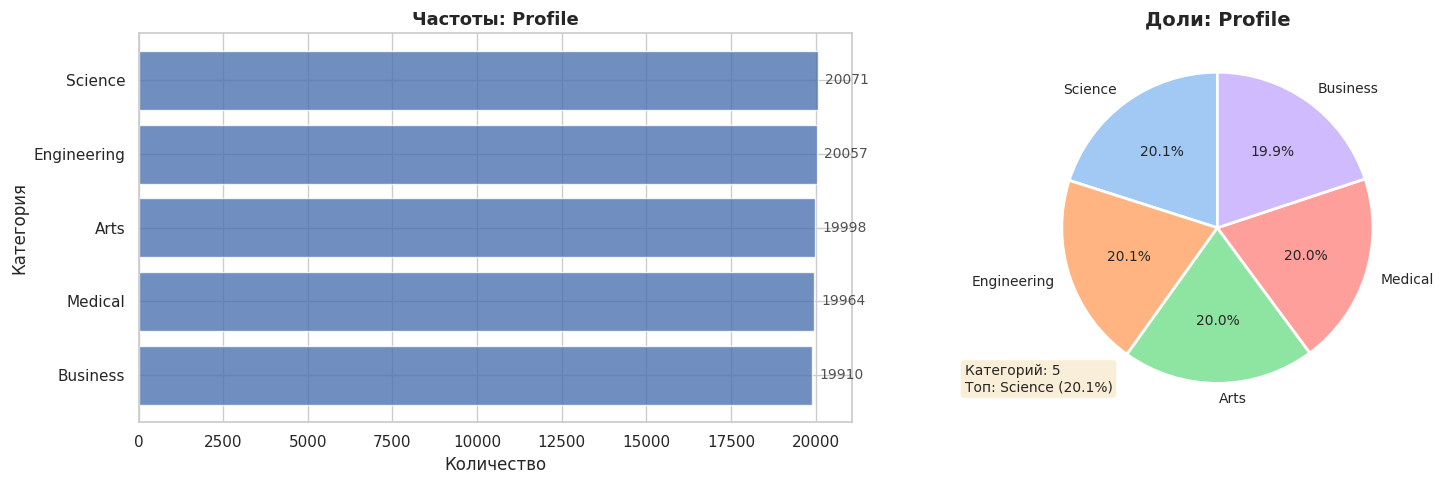

In [323]:
plot_cat_feat(eda_df["Profile"])

В датасете представлены 5 направлений обучения. Наблюдается равномерное распределение: каждая категория занимает ≈20% выборки.

### Поиск связей для регрессии

#### Анализ между числовыми признаками и целевой переменной

Проверим, как по отдельности влияют числовые признаки `Study`, `Sleep`, `Media`, `Sport`, `Stress` на успеваемость `CGPA`.

In [329]:
def plot_num_feat_vs_target(df, feat_col: str, target_col: str):
    plt.figure(figsize=(10, 4))

    sns.regplot(
        data=df,
        x=feat_col,
        y=target_col,
        scatter_kws={"alpha": 0.07, "s": 10},
        line_kws={"color": "red", "lw": 3},
    )
    plt.title(f"Влияние {feat_col} на {target_col}")

    plt.tight_layout()
    plt.show()

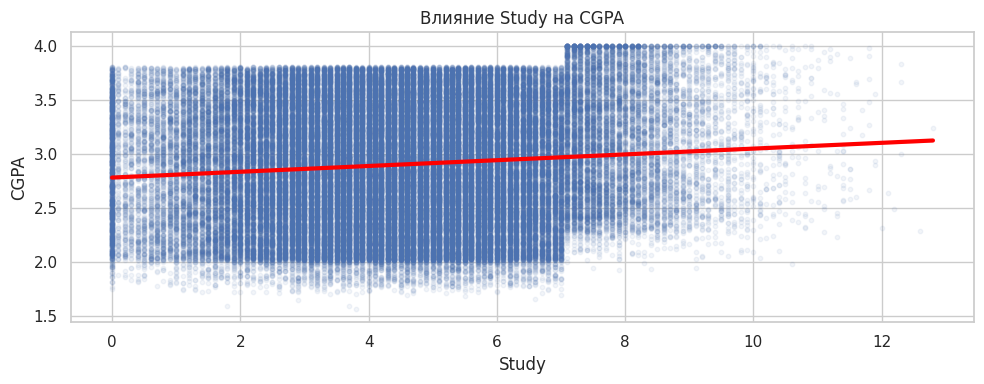

In [330]:
plot_num_feat_vs_target(eda_df, "Study", "CGPA")

Наблюдается отчетивая положительная зависимость. Линия тренда идёт вверх. Увеличение времени на обучение способствует росту академической успеваемости.

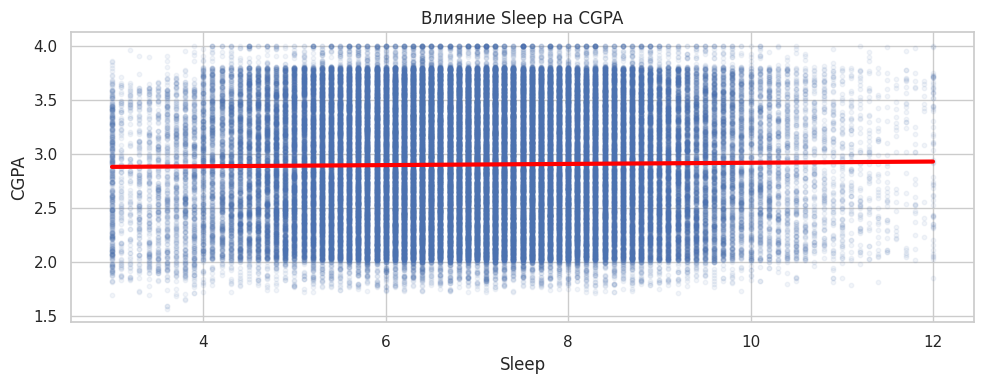

In [326]:
plot_num_feat_vs_target(eda_df, "Sleep", "CGPA")

Линия регрессии практически горизонтальна. Это указывает на крайне слабую линейную зависимость.

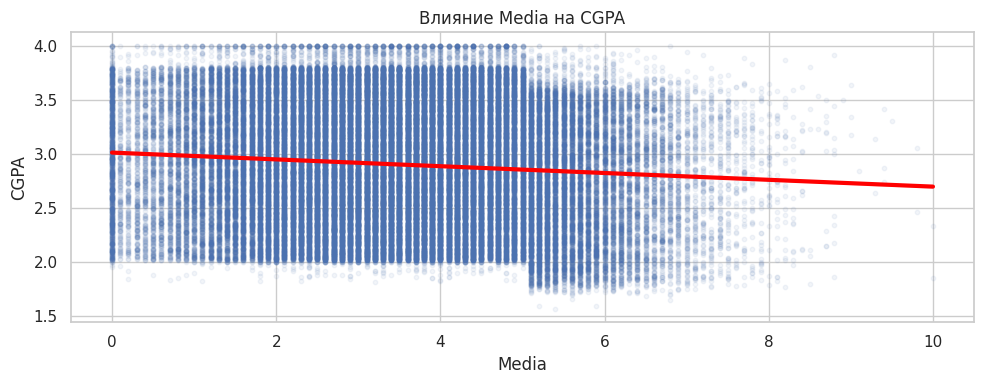

In [327]:
plot_num_feat_vs_target(eda_df, "Media", "CGPA")

Наблюдается отчетливая отрицательная зависимость. С увеличением времени, проводимого в социальных сетях, линия тренда идет вниз. Избыточное нахождение в соц-сетях негативно сказывается академической успеваемости.

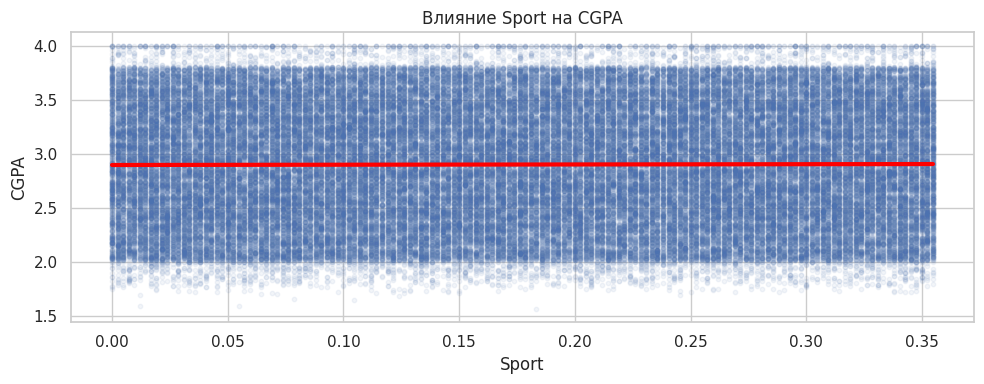

In [331]:
plot_num_feat_vs_target(eda_df, "Sport", "CGPA")

Линия регрессии практически горизонтальна. Это указывает на крайне слабую линейную зависимость.

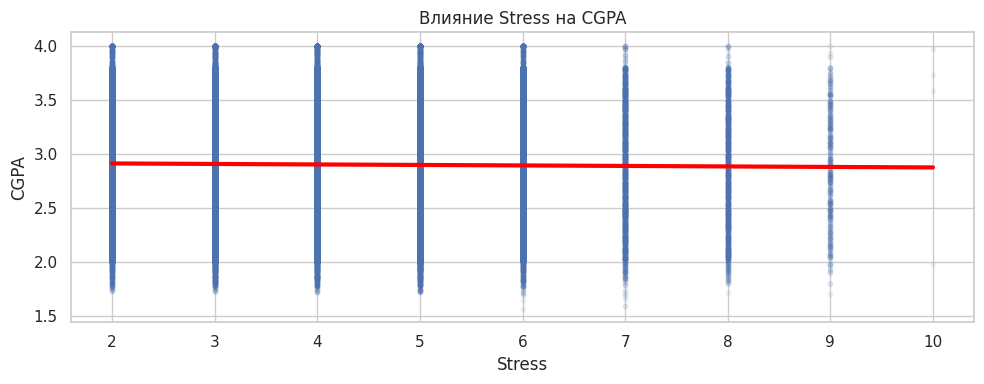

In [ ]:
plot_num_feat_vs_target(eda_df, "Stress", "CGPA")

Наблюдается слабая отрицательная зависимость.

#### Выводы на основе визуального анализа
Наблюдаются положительная связь у учебы и успеваемости и отрицательная у соцсетей и успеваемости. Однако во всех случаях наблюдается высокая дисперсия - сильный разброс точек вокруг линии тренда.

#### Анализ между категориальными признаками и целевой переменной

In [ ]:
def plot_cat_feat_vs_target(df: pd.DataFrame, feat_col: str, target_col: str):
    plt.figure(figsize=(10, 4))

    order = df.groupby(feat_col)[target_col].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df, x=feat_col, y=target_col, order=order, hue=feat_col, palette="viridis"
    )

    plt.title(
        f"Распределение {target_col} по категориям {feat_col}",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

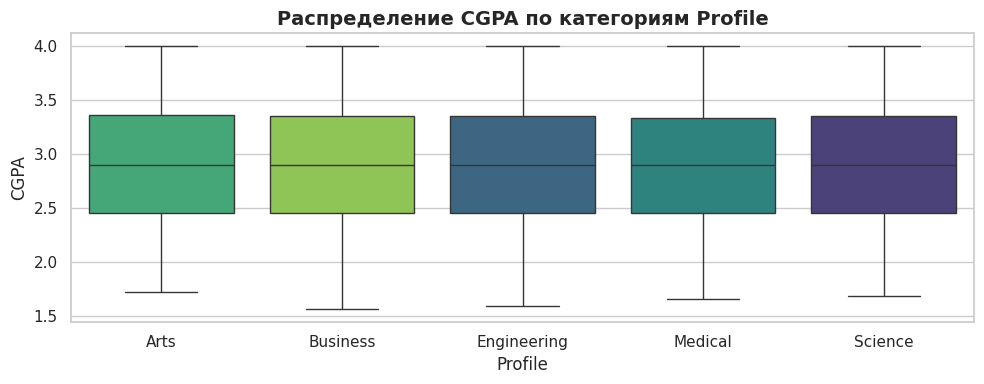

In [ ]:
plot_cat_feat_vs_target(eda_df, "Profile", "CGPA")

Медианные значения и межквартильный размах успеваемости совпадает по всем направлениям обучения. Выбор специальности не оказывает сильного влияния на академическую успеваемость.

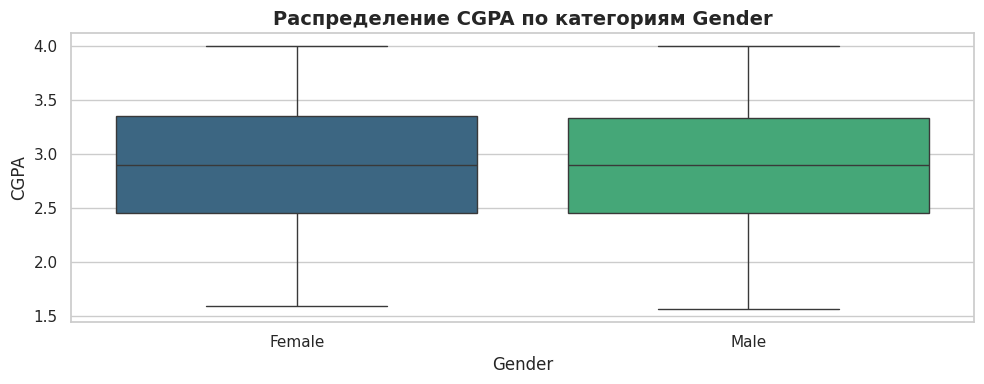

In [ ]:
plot_cat_feat_vs_target(eda_df, "Gender", "CGPA")

Медианные значения и межквартильный размах успеваемости совпадает при разделении по полу. Пол не оказывает сильного влияния на академическую успеваемость.

### Поиск связей для классификации

#### Анализ распределения числовых признаков в зависимости от депрессии

In [ ]:
def plot_num_feat_vs_cat(df: pd.DataFrame, feat_col: str, target_col: str):
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, x=target_col, y=feat_col, hue=target_col, palette="viridis")
    plt.title(
        f"Распределение {feat_col} по категории {target_col}",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

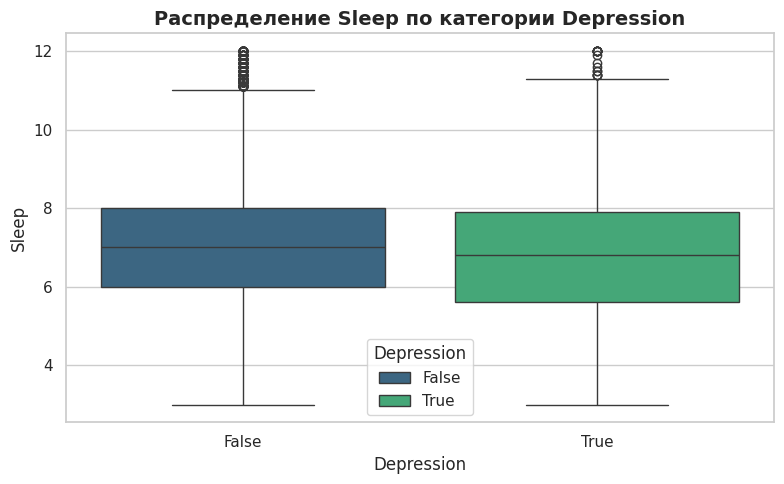

In [ ]:
plot_num_feat_vs_cat(eda_df, "Sleep", "Depression")

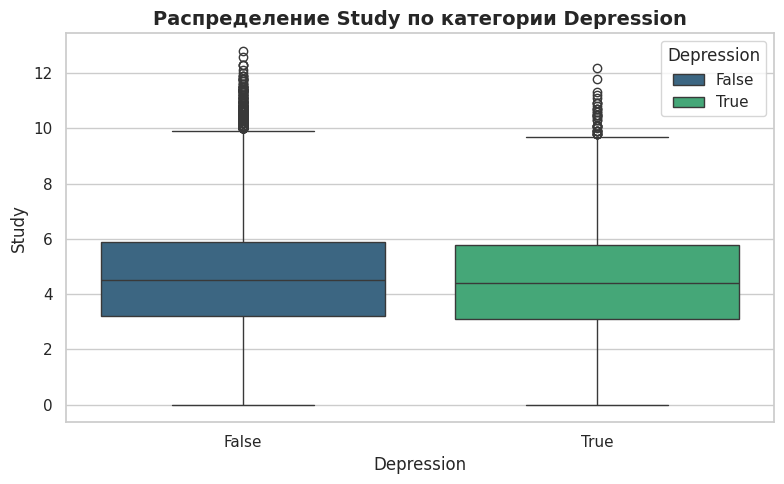

In [378]:
plot_num_feat_vs_cat(eda_df, "Study", "Depression")

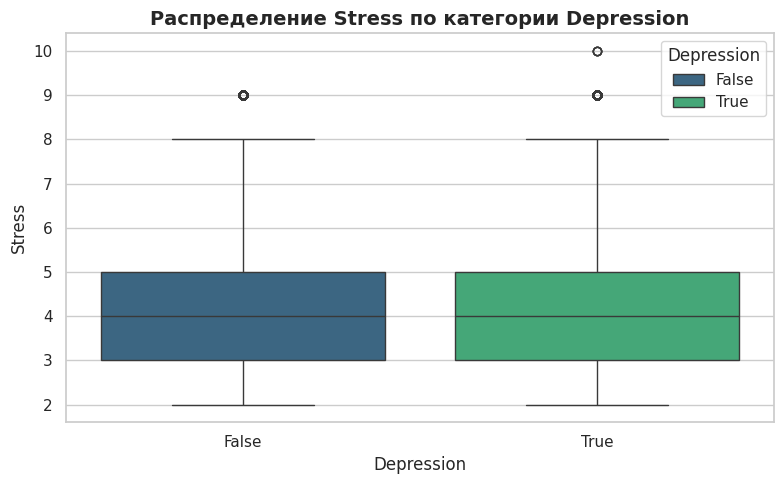

In [379]:
plot_num_feat_vs_cat(eda_df, "Stress", "Depression")

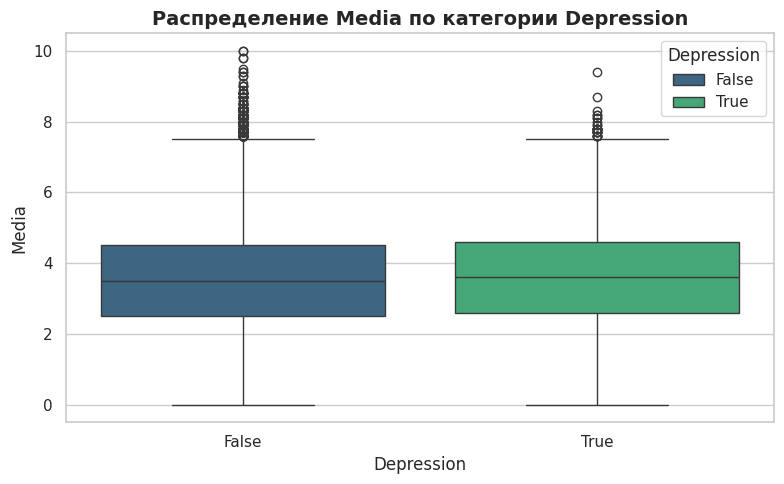

In [380]:
plot_num_feat_vs_cat(eda_df, "Media", "Depression")

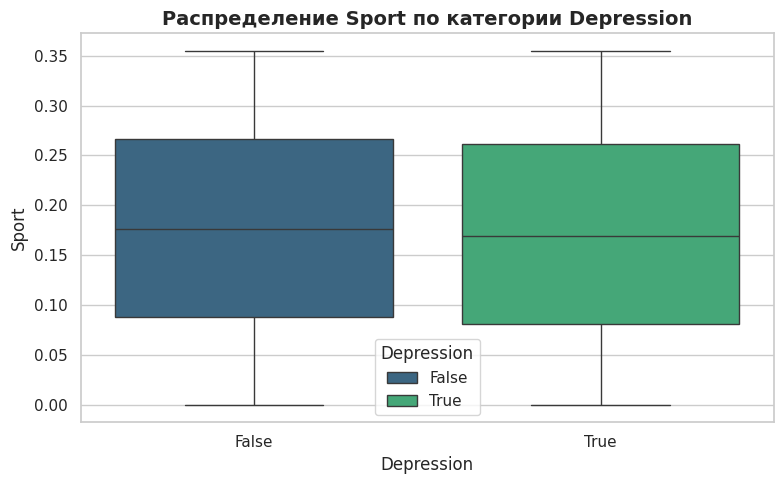

In [381]:
plot_num_feat_vs_cat(eda_df, "Sport", "Depression")

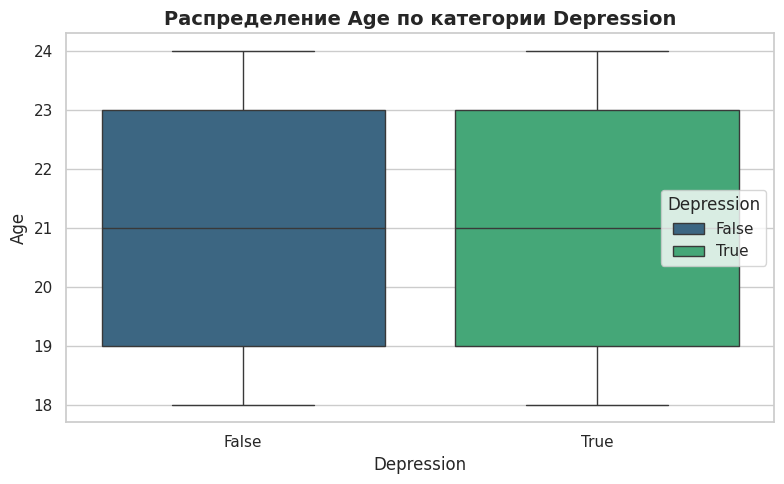

In [382]:
plot_num_feat_vs_cat(eda_df, "Age", "Depression")

#### Выводы на основе визуального анализа
Наблюдения для признаков Sleep, Study, Stress, Media и Sport показал отсутствие выраженных различий в распределениях между группами студентов с депрессией (True) и без неё (False).

#### Анализ распределения категориальных признаков в зависимости от депрессии

In [383]:
def plot_cat_feat_vs_cat(df: pd.DataFrame, feat_col: str, target_col: str):
    plt.figure(figsize=(10, 5))

    sns.countplot(data=df, x=target_col, hue=feat_col)
    plt.title(
        f"Распределение {target_col} внутри категории {feat_col}",
        fontsize=14,
        fontweight="bold",
    )
    plt.ylabel("Количество")

    plt.tight_layout()
    plt.show()

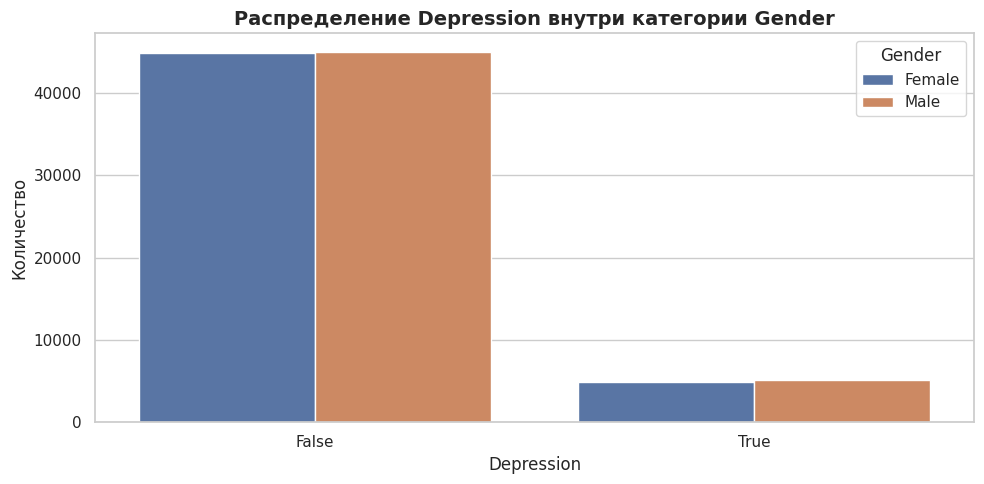

In [384]:
plot_cat_feat_vs_cat(eda_df, "Gender", "Depression")

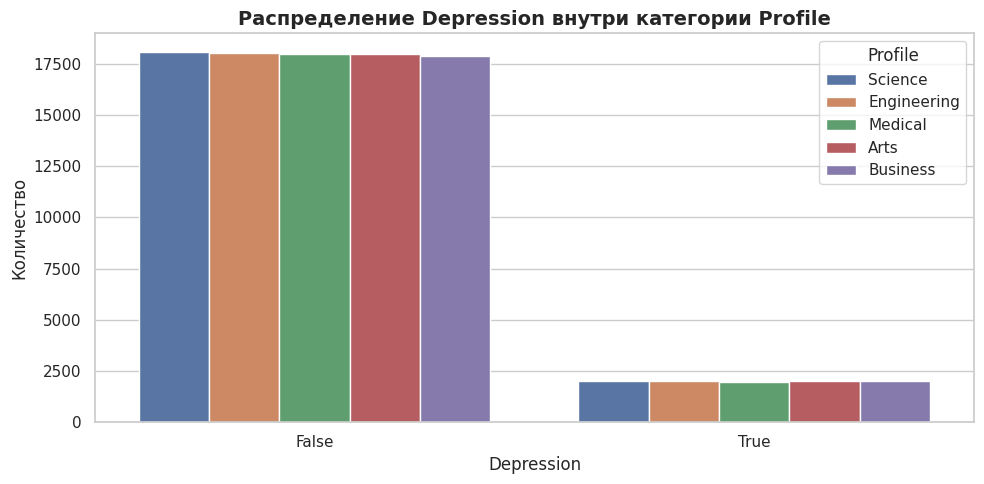

In [385]:
plot_cat_feat_vs_cat(eda_df, "Profile", "Depression")

#### Выводы на основе визуального анализа
Графики подтверждают отсутствие прямой зависимости между категориальными признаками `Gender`, `Profile` и целевой переменной Depression.

### Анализ связи между целевыми переемнными

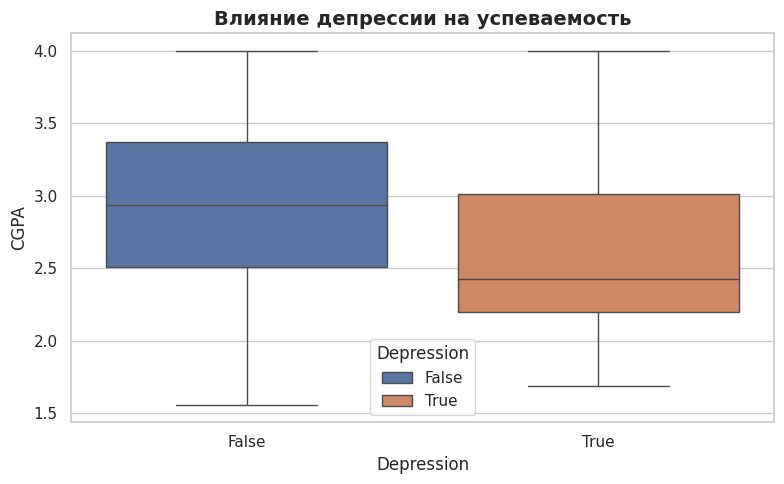

Depression
False    2.94
True     2.43
Name: CGPA, dtype: float64


In [386]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=eda_df, x="Depression", y="CGPA", hue="Depression")
plt.title("Влияние депрессии на успеваемость", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(eda_df.groupby("Depression")["CGPA"].median())

#### Выводы на основе визуального анализа
По графику видно, что наблюдается сильная отрицательная связь таргетов `Depression` и `CGPA`. Медиана успеваемости людей с депрессией (≈2.4) значительно ниже чем у здоровых (≈2.9). При этом границы ящиков (межквартильные размахи) пересекаются, но медиана группы с депрессией ниже нижней границы (Q1) здоровых людей. Это будет важным признаком для модели.

### Анализ корреляций между признаками

In [390]:
corr_df = eda_df.select_dtypes(include=["number", "bool"]).copy()
corr_df["Depression"] = corr_df["Depression"].astype(int)

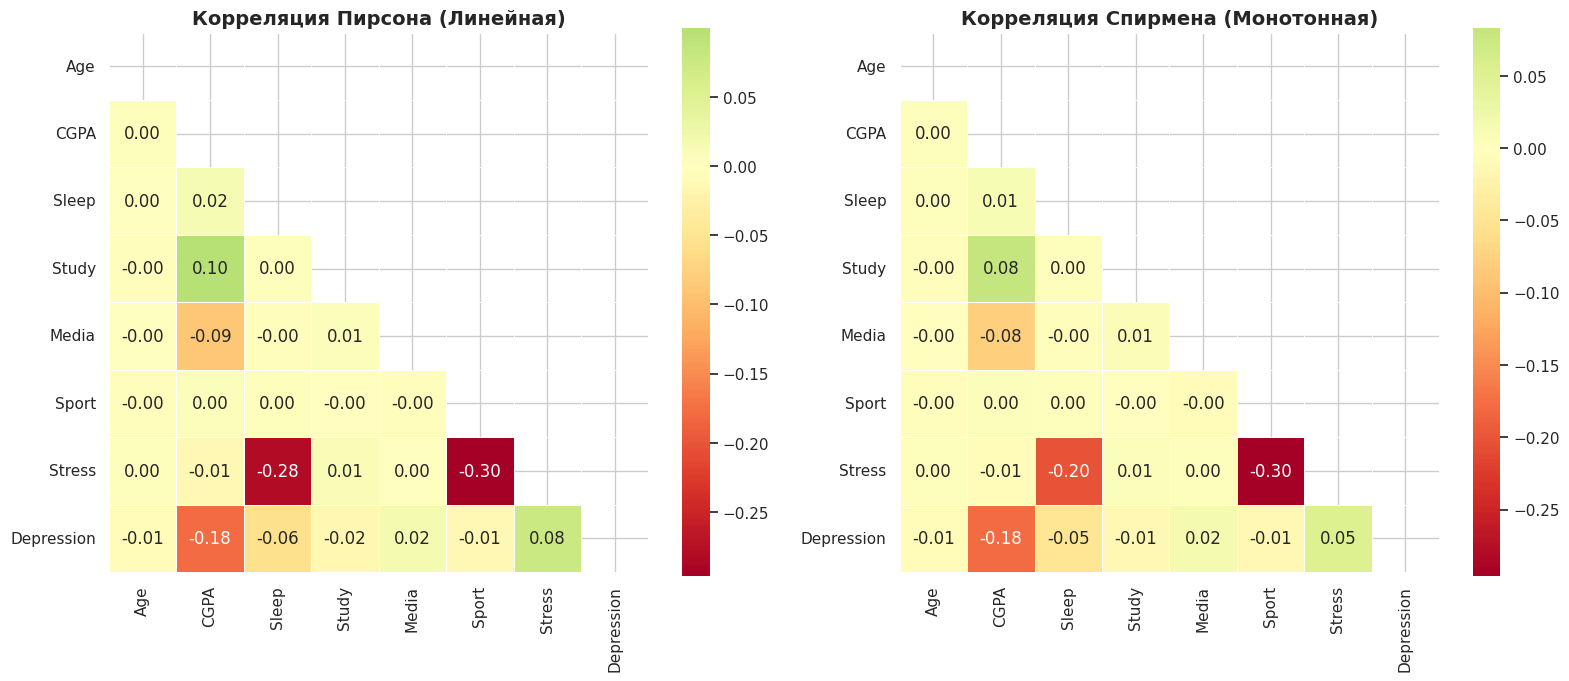

In [415]:
from typing import Literal

def plot_correlation_heatmaps(df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    methods = ["pearson", "spearman"]
    titles = ["Корреляция Пирсона (Линейная)", "Корреляция Спирмена (Монотонная)"]
    
    for ax, method, title in zip(axes, methods, titles):
        corr = df.corr(method=method)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        
        sns.heatmap(
            data=corr,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            mask=mask,
            linewidths=0.5,
            ax=ax,
            cbar_kws={"shrink": .9},
            square=True
        )
        ax.set_title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

plot_correlation_heatmaps(corr_df)

#### Выводы по корреляции
Наиболее значимый фактор для `CGPA` - наличие депрессии (-0.18). Часы учебы `Study` имеют слабую положительную связь (0.10). Выявлены отрицательные связи: спорт (-0.30) и сон (-0.28) способствуют снижению стресса. Коэффициенты Пирсона и Спирмена практически идентичны. Отсутствие высокой корреляции между признаками гарантирует отсутствие мультиколлинеарности.

## Feature Engineering
